In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense

In [3]:
mnist = tf.keras.datasets.mnist

In [4]:
(train_X, train_y),(test_X, test_y) = mnist.load_data()
print(train_X.shape)
print(test_X.shape)
# 정규화
train_X = train_X/255.0
test_X  = test_X / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(10000, 28, 28)


5


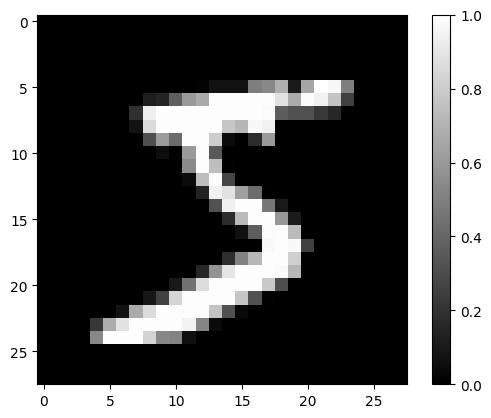

In [5]:
# 이미지 1장
plt.imshow( train_X[0], cmap="gray")
plt.colorbar()
print(train_y[0])

In [6]:
train_X = train_X.reshape( -1, 28*28) # ( 60000, 784)
test_X  = test_X.reshape(-1, 28*28)
print(train_X.shape)
print(test_X.shape)

(60000, 784)
(10000, 784)


In [10]:
# 모델의 구조,,,
model = tf.keras.Sequential(
    [
        Input( shape=(28*28,)),
        Dense( units= 784, activation="relu"), # 인코더 : 784 --> 64
        Dense( units=64, activation="relu"),   # 근원이 되는 벡터 Latent Vector (길이 64)
        Dense( units = 784,activation="relu") # 디코더 : 64 ---> 784 픽셀!!
    ]
)
model

<Sequential name=sequential, built=True>

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 716,640 (2.73 MB)

 Trainable params: 716,640 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    # 논문!! ==> 어떤 loss 을 사용했는가....관심을 가지셔야 함!!
    loss ="mse", # 개취~~기본은 이미지~~이미지~~ 픽셀의 값 자체 포커스 loss --> regression
    optimizer = tf.optimizers.Adam()
)

In [13]:
model.fit(
    train_X, # 문제지
    train_X,  # 정답지
    epochs = 20,
    batch_size = 256
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0495
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0155
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0128
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0116
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0109
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0104
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0100
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0098
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0096
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0094
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0093
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0092
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0091
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0090
Epoch 15/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


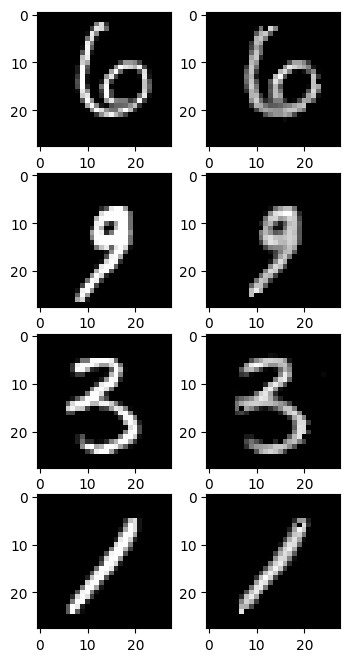

In [20]:
random_idx = [100, 1000, 5000, 8887]

plt.figure(figsize = (4, 8))
for idx in range(4):
    # 그림의 왼쪽: test할 이미지 (INPUT)
    plt.subplot(4, 2, idx*2 + 1)
    sel_idx = random_idx[idx]
    plt.imshow(test_X[sel_idx].reshape(28, 28), cmap="gray")
    # 그림의 오른쪽: 결과물 (OUTPUT)

    plt.subplot( 4,2, idx*2 +2)
    test_sample_set = np.expand_dims( test_X[sel_idx], axis=0)
    # (784,)1D ---> np.expand_dims ---> (1,784) 2D
    # + evaluate : 셋 자체 밀어넣어서,,중간 결과물을 알빠노,, 오직 평가만!!!!
    # + predict : 실제 출력을 확인!!!!
    img = model.predict(test_sample_set  ) # ===> out: ( 784,) 1D
    plt.imshow( img.reshape(28,28), cmap="gray")



### 왜 숫자가 짤려있는 것 같지?  

이유는 ReLU 때문.  
음수는 0처리, 양수는 그대로.  
그러니까, 빈 검정(0) 픽셀, 잘린 이미지 등이 보이는 것.   
  
이를 방지하기 위해서는?  


In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense

mnist = tf.keras.datasets.mnist

(train_X, train_y),(test_X, test_y) = mnist.load_data()
print(train_X.shape)
print(test_X.shape)
# 정규화
train_X = train_X/255.0
test_X  = test_X / 255.0



(60000, 28, 28)
(10000, 28, 28)


In [22]:
# conv 2D 계열을 사용하기 위해서?
# 1개 샘플은 3D, 데이터셋은 4D로 세팅.

train_X = train_X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)
print(train_X.shape, test_X.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [25]:
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Conv2DTranspose

# Conv2D: 인코더 (이미지 특징 추출 과정)
# Conv2DTranspose: 디코더 (이미지 복원 과정)
# Flatten: 인코더의 결과물이 Conv2D (3차원 FM). 잠재공간 1D Vector화: 단순하게 1차원 모양으로 변경하는 역할
# Dense: 1차원에서 펼쳐진 벡터들을 내가 원하는 Latent Vector 사이즈로 조절.


In [29]:
model = tf.keras.Sequential(
    [
        # 입력레이터 --> 1개 : (28,28,1)
        Input( shape=(28,28,1)),

        # 인코더 파트!! : VGG 일반적인 이미지 특징 추출하는 과정 Conv-Conv
        Conv2D( kernel_size=2, filters=32, strides=(2,2), activation="relu"),
        # ===> (14,14,32)
        Conv2D( kernel_size=2, filters=64, strides=(2,2), activation="relu"),
        # ===> (7,7,64)
        # 참고) Inception V1은 이 부분을 AvgPool--> (1,1,64) 저는 그냥 하겠다!!!

        # 잠재벡터 -===> 1D( 길이 : 64 )
        # 3차원의 (7,7,64)----> 1차원 길이 64인 벡터로 응축!!
        # 일단 3차원을 ,,1차원으로 변경,,, ---> 64개로 압축(1차원)
        Flatten(), # (3136,) 1D
        #----------------------------------------------------------------
        # +++++
        Dense( units=64, activation="relu"), # (64,) 1D Latent Vector ***
        # +++++
        # ----------------------------------------------------------------
        # 디코더,.,
        # 개취 : 완벽하게 대칭형으로 디코더부분을 하겠다!!!
        # 1차원 (64,)---> 1차원(3136,) 1차원 벡터 확장
        Dense( units=7*7*64, activation="relu"), # (3136,) 1d

        # (3136,)1d ---> (7,7,64)3d==> Reshape
        tf.keras.layers.Reshape( target_shape=( 7,7,64)),

        # Conv2D 대칭인 디코더 파트!!
        # Conv2D : 모양중심(W/H) 코드를 작성할테니,,, 채널은 니가 해줘~~~~
        # Conv2DTranspose : 채널 중심으로 코드 작성,,,모양은 니가 해줘~~~~
        # (7,7,64) --> (14,14, 32)
        Conv2DTranspose( filters= 32, kernel_size=2, strides=(2,2), activation="relu"),
        # (14,14,32) ---> (28,28,1)
        Conv2DTranspose( filters= 1, kernel_size=2, strides=(2,2), activation="sigmoid"),
        # --> (28,28,1)
        # AF : relu를 사용해도 되기는 하는데,,,,약간 뭔가 이상합니다;;
        #    : 입력 이미지 픽셀값~~~~~ 출력 이미지 픽셀값
        #           정규화(0~1)
        #    출력에 대한 값도,,,,0~1사이로 컨트롤 하기 위해서,,맨 마지막은
        #    개취로 sigmoid
    ]
)
model

<Sequential name=sequential_3, built=True>

In [30]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           129 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,377 (1.61 MB)

 Trainable params: 421,377 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    # 논문!! ==> 어떤 loss 을 사용했는가....관심을 가지셔야 함!!
    loss ="mse", # 개취~~기본은 이미지~~이미지~~ 픽셀의 값 자체 포커스 loss --> regression
    optimizer = tf.optimizers.Adam()
)


model.fit(
    train_X, # 문제지
    train_X,  # 정답지
    epochs = 20,
    batch_size = 256
)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 0.1189
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.0359
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.0249
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0223
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0212
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - loss: 0.0205
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0200
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0197
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - loss: 0.0193
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.0193
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0192
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0190
Epoch 13/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - loss: 0.0189
Epoch 14/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - loss: 0.0189
Epoch 15/20
235/235 ━━━━━━━━━